In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from model_runner import run_model, water_balance_report, write_simulation_report, get_logger
from config_loader import write_inputs_report

#segoe ui font for better readability
plt.rcParams['font.family'] = 'Segoe UI'

In [2]:
# ---- files ----
paths_nml = Path("paths.nml")
run_nml   = Path("run.nml")
params_nml = Path("parameters.nml")
scenario_nml = Path("scenario.nml")

# ----  Run model ----
logger = get_logger(level=20)  # INFO

raw, forcing, fluxes, df_all, df_trim = run_model(
    paths_nml=paths_nml,
    run_nml=run_nml,
    params_nml=params_nml,
    scenario_nml=scenario_nml,
    I0=0.0,
    sm0_mode="fc",
    logger=logger
)

# ---- reports ----
log_path = write_inputs_report(raw, filename="inputs_report.log")
write_simulation_report(raw, filename="simulation_report.txt")
water_balance_report(raw, forcing, df_all, filename="water_balance_report.txt")

2026-05-20 16:51:01,075 | INFO | Loaded raw inputs: 1990-01-01 -> 2025-12-31
2026-05-20 16:51:01,080 | INFO | Scenario applied: more_forest | landcover = [{'lu_type': 'Bare', 'lu_frac': 0.15}, {'lu_type': 'Deciduous broadleaf forest', 'lu_frac': 0.25}, {'lu_type': 'Grassland', 'lu_frac': 0.6}]
2026-05-20 16:51:06,907 | INFO | Built forcing (H): 315576 steps
2026-05-20 16:51:06,913 | INFO | Prepared LU inputs: 3 LU types


Running Canopy WB (multi-LU):   0%|          | 0/315576 [00:00<?, ?it/s]

2026-05-20 16:51:13,580 | INFO | Canopy WB complete.


Running Land Surface WB (multi-LU):   0%|          | 0/315576 [00:00<?, ?it/s]

2026-05-20 16:53:09,351 | INFO | Soil WB complete.


WindowsPath('W:/VUB/_main_research/scripts/wetland_model/conceptual_model/model_setup_v2_2025/outputs/water_balance_report.txt')

In [3]:
raw.soil_params_layer

{'theta_sat': array([0.49171937, 0.49171937, 0.49171937, 0.49171937]),
 'theta_fc': array([0.27399807, 0.27399807, 0.27399807, 0.27399807]),
 'theta_wp': array([0.08643796, 0.08643796, 0.08643796, 0.08643796]),
 'theta_r': array([0.01, 0.01, 0.01, 0.01]),
 'alpha': array([0.01740714, 0.01740714, 0.01740714, 0.01740714]),
 'vG_n': array([1.33077342, 1.33077342, 1.33077342, 1.33077342]),
 'vG_m': array([0.24855728, 0.24855728, 0.24855728, 0.24855728]),
 'Ks_cm_day': array([106.77538599, 106.77538599, 106.77538599, 106.77538599])}

### Validation

In [4]:
#get current working directory
cwd = Path().resolve()

#MODIS ET and PET
modis_ET = pd.read_csv(cwd / "inputs" / "validation" / "MOD16A2GF_ET_PET_mm_day_500m.csv", parse_dates=['date'], index_col='date')

#### Validation with observations

(0.0, 38.063028058258865)

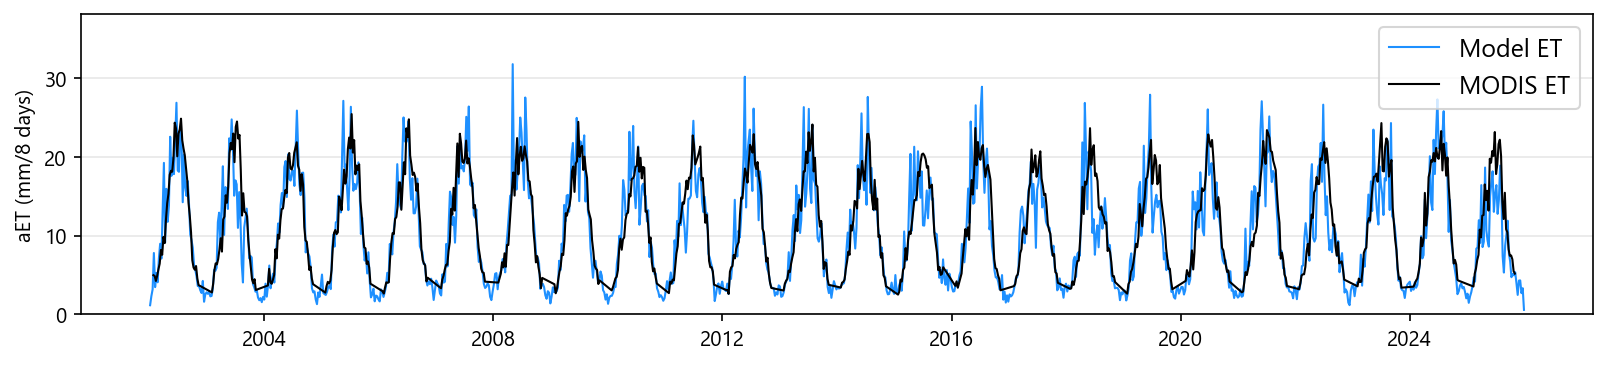

In [5]:
variable_name = 'total_evap'  # Change this to the desired variable name from df_trim
fig, ax = plt.subplots(figsize=(13, 2.6), dpi=150)

start_date = '2002-01-01'
end_date = '2025-12-31'

flux_mon = df_trim.resample('8D').sum()
# ax.plot(flux_mon['pet'].resample('8D').sum()[start_date:end_date], label='MODEL PET', color='k', linestyle='--')
ax.plot(flux_mon[variable_name][start_date:end_date], label='Model ET', color='dodgerblue', lw=1.0)
ax.plot((modis_ET['ET_mm_day']*8)[start_date:end_date], label='MODIS ET', color='k', lw=1.0)
# ax.plot((modis_ET['PET_mm_day']*8)[start_date:end_date], label='MODIS PET', color='red', linestyle='--', lw=1.0)
ax.set_ylabel('aET (mm/8 days)')
plt.legend(ncols=1, fontsize=12)
plt.grid(axis='y', alpha=0.3)
ax.set_ylim(0, flux_mon[variable_name][start_date:end_date].max()*1.2)

#### ET statistics

In [6]:
#compare mean model ET with MODIS ET
mean_model_et = flux_mon[variable_name][start_date:end_date].resample('YE').sum().mean()
mean_modis_et = (modis_ET['ET_mm_day']*8)[start_date:end_date].resample('YE').sum().mean()
print(f"Mean Model ET (2000-2025): {mean_model_et:.2f} mm/year")
print(f"Mean MODIS ET (2000-2025): {mean_modis_et:.2f} mm/year")

Mean Model ET (2000-2025): 464.81 mm/year
Mean MODIS ET (2000-2025): 448.37 mm/year


RMSE between Model ET and MODIS ET: 3.76 mm/8 days


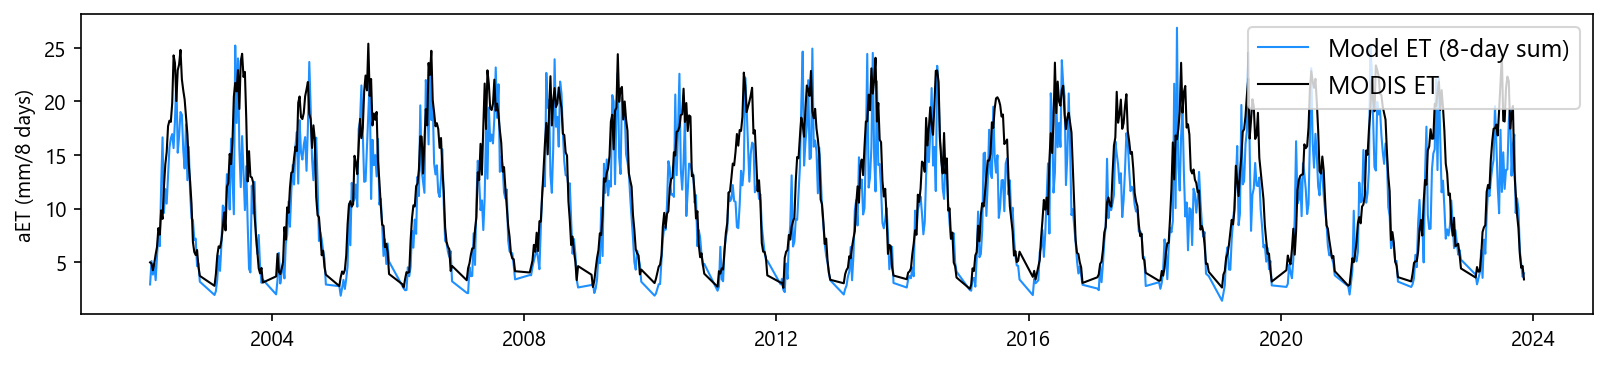

In [17]:
modis_start = modis_ET.index.min()
modis_end = modis_ET.index.max()

#subset model data to match MODIS period
model_ET = df_trim['total_evap']

modis_windows = []
#sum modelled to match MODIS ET 8-day period
for index in modis_ET.index:  # Exclude the last index to avoid out-of-range error
    start = index-pd.Timedelta(days=7)
    end = index
    flux_interval = model_ET[(model_ET.index >= start) & (model_ET.index <= end)]
    window_sum = flux_interval.sum()
    modis_windows.append(window_sum)

#convert to dataframe
modis_windows_df = pd.DataFrame(modis_windows, index=modis_ET.index, columns=[variable_name])

#plot modelled ET in the same 8-day windows as MODIS
fig, ax = plt.subplots(figsize=(13, 2.6), dpi=150)
ax.plot(modis_windows_df[variable_name][start_date:end_date], label='Model ET (8-day sum)', color='dodgerblue', lw=1.0)
ax.plot((modis_ET['ET_mm_day']*8)[start_date:end_date], label='MODIS ET', color='k', lw=1.0)
ax.set_ylabel('aET (mm/8 days)')
plt.legend(ncols=1, fontsize=12)

#RMSE between model ET and MODIS ET
def rmse(y_true, y_pred):
    error = y_true - y_pred
    mse = (error ** 2).mean()
    return mse ** 0.5

rmse_et = rmse(modis_windows_df[variable_name][start_date:end_date], (modis_ET['ET_mm_day']*8)[start_date:end_date])
print(f"RMSE between Model ET and MODIS ET: {rmse_et:.2f} mm/8 days")


### Validate soil moisture

In [8]:
#present dir
import os
p_dir= r'W:\VUB\_main_research\scripts\wetland_model\conceptual_model\model_setup_v2_2025\inputs\validation'

smap_sm = pd.read_excel(os.path.join(p_dir, "smap_surface_sm_boechout_9km.xlsx"), parse_dates=['date'], index_col='date')
smap_sm = smap_sm.resample('D').mean().dropna()[start_date:end_date]
smap_sm_daily = smap_sm.resample('D').mean()

#sm TMS
insitu_sm = pd.read_csv(os.path.join(p_dir, "pred_vwc_BOE_D2.csv"), parse_dates=['datetime'], index_col='datetime')
insitu_sm.columns = ['vwc']

#observed sm with curieuze neuzen data
insitu_sm_cn = pd.read_excel(cwd / "inputs" / "validation" / "curieuze_neuzen sensors.xlsx", parse_dates=['Date'], index_col='Date')
#set index to datetime
insitu_sm_cn.index = pd.to_datetime(insitu_sm_cn.index, format='%d/%m/%Y')
list_CN_sensors = list(insitu_sm_cn['SensorID'].unique())


# smap_sm = pd.read_csv(os.path.join(p_dir, "SMAP_L4_sm_surface_rootzone_9km_native.csv"), index_col='datetime')
# smap_sm.index = pd.to_datetime(smap_sm.index, format='%Y-%m-%d %H:%M')
# smap_sm_daily = smap_sm.resample('D').mean()

In [9]:
insitu_sm_cn

,Site_id,SensorID,Latitude,Longitude,Temp_Sensor1,Temp_Sensor2,Temp_Sensor3,SoilMoisture_Sensor,SoilMoisture_Model,Recharge_Model,Model_AET
Date,,,,,,,,,,,
2021-04-04,4392,97313228,51.194725,4.53104,9.818359,7.685547,7.378906,0.181655,0.895812,0.051113,0.154086
2021-04-05,4392,97313228,51.194725,4.53104,8.826271,5.524364,4.908898,0.188097,0.895103,0.055949,0.014398
2021-04-06,4392,97313228,51.194725,4.53104,7.125000,2.470170,2.015625,0.239381,0.904879,0.174434,0.000000
2021-04-07,4392,97313228,51.194725,4.53104,6.347561,4.506098,4.224085,0.295369,0.912312,0.256976,0.065168
2021-04-08,4392,97313228,51.194725,4.53104,7.283654,6.687500,6.330357,0.287589,0.909517,0.223969,0.234482
...,...,...,...,...,...,...,...,...,...,...,...
2022-09-24,51461,97316460,51.157942,4.48938,14.722656,13.534505,12.791016,0.449388,0.839801,0.082403,0.000000
2022-09-25,51461,97316460,51.157942,4.48938,14.455729,13.045573,12.317057,0.442960,0.843938,0.081201,0.133001
2022-09-26,51461,97316460,51.157942,4.48938,14.041667,11.927083,11.210286,0.441999,0.867674,0.120131,0.000000


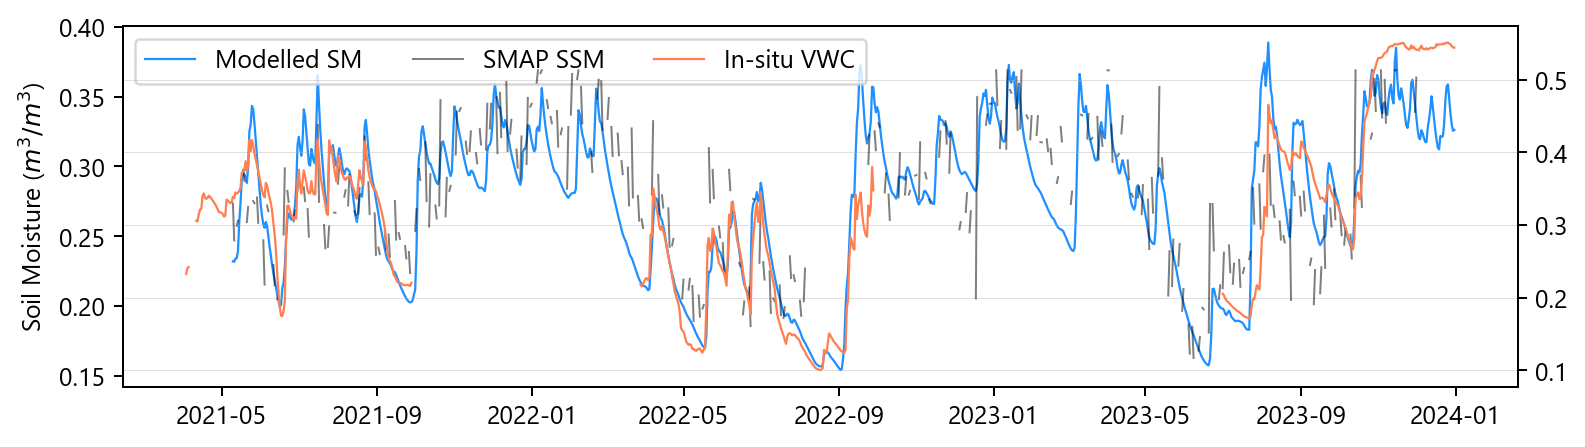

In [27]:
fig, ax = plt.subplots(figsize=(10, 2.6), dpi=180)
ax1=ax.twinx()

flux = df_trim['soil_moisture_L2']  # Change this to the desired soil moisture variable from df_trim

#2021 data: 18, 21, 30
data_2021 = insitu_sm_cn[insitu_sm_cn['SensorID']==list_CN_sensors[21]]

#2022 data: 11,22,24,3,7|| Both 6,9
data_2022 = insitu_sm_cn[insitu_sm_cn['SensorID']==list_CN_sensors[11]]

start_date_smap = '2021-05-10'
end_date = '2023-12-31'

flux_mon =flux.resample('D').mean()
ax1.plot(smap_sm_daily[start_date_smap:end_date], label='SMAP SSM', color='k', lw=0.8, alpha=0.5)
ax.plot(flux_mon[start_date_smap:end_date], label='Modelled SM', color='dodgerblue', lw=0.9)
ax1.plot(insitu_sm['vwc'][start_date_smap:end_date], label='In-situ VWC', color='coral', lw=0.9)

#in situ sm with curieuze neuzen data
ax1.plot(data_2021['SoilMoisture_Sensor'], color='coral', lw=0.9)
ax1.plot(data_2022['SoilMoisture_Sensor'], color='coral', lw=0.9)

ax.set_ylabel('Soil Moisture ($m^3/m^3$)')

#remove ax1 ticks and labels
# ax1.set_yticks([])
# ax1.set_ylabel('')

#collect legend handles and labels from both axes
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax1.get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2
ax.legend(handles, labels, ncol=3, fontsize=10)
plt.grid(axis='y', alpha=0.4, lw=0.4)


Text(0, 0.5, 'Surface Runoff (mm)')

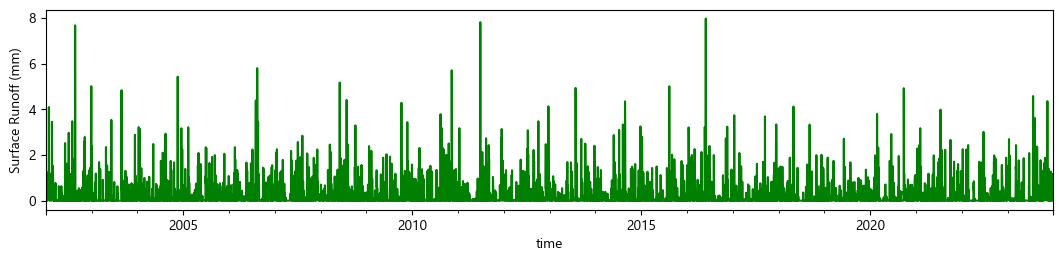

In [11]:
df_trim['surface_run_off'].resample('D').sum()[start_date:end_date].plot(figsize=(13,2.6), color='green', label='Surface Runoff')
plt.ylabel('Surface Runoff (mm)')

<Axes: xlabel='time'>

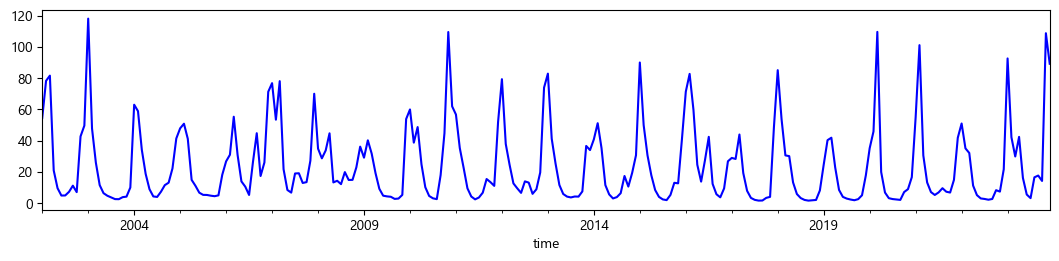

In [12]:
df_trim['recharge_L4'].resample('ME').sum()[start_date:end_date].plot(figsize=(13,2.6), color='blue', label='Recharge')

In [13]:
# If df_main is hourly fluxes in mm per timestep:
annual = df_trim.resample("YE").sum()

annual_precip = annual["pre"].mean()
annual_evap   = annual["total_evap"].mean()
annual_runoff = annual["surface_run_off"].mean()
annual_rech   = annual["recharge_L4"].mean()   # <-- use bottom layer recharge (adjust L4 to N)

print("Annual Mean Precipitation:", annual_precip)
print("Annual Mean Evapotranspiration:", annual_evap)
print("Annual Mean Surface Runoff:", annual_runoff)
print("Annual Mean Deep Recharge:", annual_rech)
print("Water Balance Check (P - ET - R - Q):", annual_precip - annual_evap - annual_rech - annual_runoff)
annual_evap/annual_precip

Annual Mean Precipitation: 848.0094168933265
Annual Mean Evapotranspiration: 462.5409871803672
Annual Mean Surface Runoff: 77.09151842750578
Annual Mean Deep Recharge: 310.0753681763622
Water Balance Check (P - ET - R - Q): -1.6984568909086875


0.5454432202827195

In [14]:
annual_bs_evap = annual['evap_actual_bs'].mean()
annual_canopy_evap = annual['canopy_evap'].mean()
annual_L1_evap = annual['aET_L1'].mean()
annual_L2_evap = annual['aET_L2'].mean()
annual_L3_evap = annual['aET_L3'].mean()
annual_L4_evap = annual['aET_L4'].mean()

print("Annual Mean Bare Soil Evaporation:", annual_bs_evap)
print("Annual Mean Canopy Evaporation:", annual_canopy_evap)
print("Annual Mean L1 Evaporation:", annual_L1_evap)
print("Annual Mean L2 Evaporation:", annual_L2_evap)
print("Annual Mean L3 Evaporation:", annual_L3_evap)
print("Annual Mean L4 Evaporation:", annual_L4_evap)

Annual Mean Bare Soil Evaporation: 51.570790438116234
Annual Mean Canopy Evaporation: 111.32418067721386
Annual Mean L1 Evaporation: 16.523822193924904
Annual Mean L2 Evaporation: 152.80916417531108
Annual Mean L3 Evaporation: 59.45436048586902
Annual Mean L4 Evaporation: 70.85866920993203


In [15]:

can_ec_ratio = df_trim['canopy_evap']/ df_trim['total_evap']
